### IMPORTS

In [1]:
import pandas as pd

In [2]:
from data_ingestion import data_ingest
from data_transformation import data_transform, segmentation

### DATA INGESTION

In [3]:
# START FETCHING BITCOIN PRICES WITH AN INTERVAL OF 1 MIN AND SAVE IN DATAFRAME
# data_ingest()

In [4]:
df = pd.read_csv("data.csv")
df.head()

,time,price,date
0,22:11:03.919435,84218,2025-04-13
1,22:12:04.032894,84243,2025-04-13
2,22:13:04.158747,84257,2025-04-13
3,22:14:04.277375,84268,2025-04-13
4,22:15:04.415592,84238,2025-04-13


### DATA TRANSFORMATION

In [5]:
# Feature engineering and creating window for data segmentation
df = data_transform(df, window=5)
df.head()

2025-05-01 12:32:52.737 | INFO     | data_transformation:data_transform:27 - Segmented data with window size of: 5


,time,price,date,perc_change,movement,window
0,22:11:03.919435,84218,2025-04-13,0.000000,stable,0
1,22:12:04.032894,84243,2025-04-13,0.029685,medium_up,0
2,22:13:04.158747,84257,2025-04-13,0.016619,stable,0
3,22:14:04.277375,84268,2025-04-13,0.013055,stable,0
4,22:15:04.415592,84238,2025-04-13,-0.035601,medium_down,0


In [6]:
# Segmenting data into documents basis window size of 5
documents = segmentation(df)
documents[:5]

2025-05-01 12:32:52.744 | INFO     | data_transformation:segmentation:34 - Segmented data into documents


[['stable', 'medium_up', 'stable', 'stable', 'medium_down'],
 ['stable', 'large_up', 'stable', 'medium_up', 'stable'],
 ['medium_up', 'stable', 'stable', 'stable', 'stable'],
 ['medium_up', 'large_up', 'medium_up', 'medium_up', 'large_up'],
 ['large_up', 'large_up', 'medium_up', 'large_up', 'large_up']]

### VECTORIZATION

In [7]:
from vectorization import word2vec, fasttext, doc_tagger, do2vec

In [8]:
# Creating a Word2Vec Model
w2v_model = word2vec(documents)

# Creating a FastText Vector Model
ft_model = fasttext(documents)

# Creating a Doc2Vec Model
tagged_docs = doc_tagger(documents)
d2v_model = do2vec(tagged_docs)

2025-05-01 12:32:53.156 | INFO     | vectorization:word2vec:8 - Vectorization completed using Word2Vec Model
2025-05-01 12:32:53.411 | INFO     | vectorization:fasttext:13 - Vectorization completed using Fast Text Model
2025-05-01 12:32:53.411 | INFO     | vectorization:doc_tagger:18 - Document Tagging completed
2025-05-01 12:32:53.423 | INFO     | vectorization:do2vec:24 - Document Vectorization completed using Doc2Vec Model


### TOPIC MODELING

In [9]:
from topic_modeling import corpus_creation, lda_modeling, lsi_modeling

In [10]:
# Creating dictionary and corpus for our topic models
dictionary, corpus = corpus_creation(documents)

# Creating LDA Model with 2 topics
lda_model = lda_modeling(dictionary, corpus, num_topics=2)

# Creating LSI Model with 2 topics
lsi_model = lsi_modeling(dictionary, corpus, num_topics=2)

# By the topic scoring we can get an idea of whether the topic is bullish, bearish or stable
# Insight you get:

# Topic 0 = Bearish periods 
# (since 80% of tokens are either 'stable' or 'medium_down/large_down')
# '0.645*"stable" + 0.223*"medium_down" + 0.060*"large_down" + 0.056*"medium_up" + 0.017*"large_up"'

# Topic 1 = Bulllish periods 
# '0.526*"large_up" + 0.371*"medium_up" + 0.050*"stable" + 0.031*"medium_down" + 0.022*"large_down"'
# (90% up)
# '''

2025-05-01 12:32:53.432 | INFO     | topic_modeling:corpus_creation:10 - Dictionary and Corpus created for Topic Modeling


LDA Modeling done with following topics
(0, '0.906*"stable" + 0.085*"medium_up" + 0.004*"medium_down" + 0.003*"large_up" + 0.002*"large_down"')
(1, '0.267*"medium_down" + 0.257*"stable" + 0.210*"medium_up" + 0.193*"large_up" + 0.072*"large_down"')
LSI Modeling done with following topics
(0, '0.992*"stable" + 0.106*"medium_up" + 0.060*"medium_down" + 0.026*"large_up" + 0.014*"large_down"')
(1, '0.802*"medium_up" + 0.587*"large_up" + -0.098*"stable" + -0.047*"medium_down" + -0.012*"large_down"')


### ANALYSIS

In [11]:
from analysis import vector_model_topic_similarity, vecmodel_window_similarity, similar_d2v_time, similar_w2v_time, d2v_cosine_sim, word2v_cosine_sim, topic_model_cos_sim, sub_dataframe

In [12]:
similarity_df_w2v = vector_model_topic_similarity(w2v_model)
print("Similarity matrix based on Word2Vec Model")
print(vector_model_topic_similarity.__doc__)
print(similarity_df_w2v)

similarity_df_fasttext = vector_model_topic_similarity(ft_model)
print("Similarity matrix based on FastText Model")
print(vector_model_topic_similarity.__doc__)
print(similarity_df_fasttext)

similarity_df_d2v = vector_model_topic_similarity(d2v_model)
print("Similarity matrix based on Doc2Vec Model")
print(vector_model_topic_similarity.__doc__)
print(similarity_df_d2v)

Similarity matrix based on Word2Vec Model

    What does function tells? Basis similarity matrix we can conclude -
    In a trending market, "large_up" might be highly similar to "large_down"
    In a volatile market, "large_up" might be highly similar to "medium_down"
    
               stable  medium_up  medium_down  large_up  large_down
stable       1.000000   0.056507     0.133226 -0.002911   -0.112644
medium_up    0.056507   1.000000     0.016674 -0.163587    0.128055
medium_down  0.133226   0.016674     1.000000 -0.149741    0.166800
large_up    -0.002911  -0.163587    -0.149741  1.000000   -0.202517
large_down  -0.112644   0.128055     0.166800 -0.202517    1.000000
Similarity matrix based on FastText Model

    What does function tells? Basis similarity matrix we can conclude -
    In a trending market, "large_up" might be highly similar to "large_down"
    In a volatile market, "large_up" might be highly similar to "medium_down"
    
               stable  medium_up  medium_d

In [13]:
# Selecting documents
doc1 = documents[3]
doc2 = documents[-1]

print(vecmodel_window_similarity.__doc__)
print("Doc1:",doc1)
print("Doc2:",doc2)

# Similarity based on Word2Vec Model
vecmodel_window_similarity(w2v_model, doc1, doc2)

# Similarity based on FastText Model
vecmodel_window_similarity(ft_model, doc1, doc2)

# Similarity based on Doc2Vec Model
vecmodel_window_similarity(d2v_model, doc1, doc2)

Checking similarity between segmented data (2 documents) using vectorization model
Doc1: ['medium_up', 'large_up', 'medium_up', 'medium_up', 'large_up']
Doc2: ['stable', 'stable', 'stable', 'medium_up']
Similarity: 0.2602
Similarity: 0.2468
Similarity: 0.2677


In [14]:
doc = documents[-1]

# Finding top 5 similar documents/timeframes to the given document
print(similar_d2v_time.__doc__)
similar_d2v_time(df, d2v_model, doc)


    Finding top 5 similar documents/timeframes to the given document.
    So that we can check what is the most similar history and it's result to invest accordingly
    
Top 5 similar timeframes
Timeframe: 2025-04-13, 23:01:10.564831 To 2025-04-13, 23:05:11.091273 Similarity: 0.40441516041755676
Timeframe: 2025-04-28, 20:44:20.231303 To 2025-04-29, 12:52:21.419603 Similarity: 0.3213822841644287
Timeframe: 2025-04-29, 13:49:22.383113 To 2025-04-29, 13:53:22.940405 Similarity: 0.2815965712070465
Timeframe: 2025-04-29, 13:03:23.201708 To 2025-04-29, 13:07:23.718568 Similarity: 0.26437047123908997
Timeframe: 2025-04-28, 19:37:05.607066 To 2025-04-28, 19:41:06.315821 Similarity: 0.2638338506221771


In [15]:
index = -1
doc = documents[index]

print(similar_w2v_time.__doc__)

print("\nTimestamp for which we are finding similar windows")
print(sub_dataframe(df, index))

print("\nSimilar windows based on Word2Vec Model")
similar_w2v_time(df, w2v_model, documents, doc, topn=5)

print("\nSimilar windows based on FastText Model")
similar_w2v_time(df, ft_model, documents, doc, topn=5)


    Finds top N similar windows to a given new_doc using Word2Vec or FastText.
    

Timestamp for which we are finding similar windows
time           21:59:14.735654
price                    94502
date                2025-04-29
perc_change           0.029638
movement             medium_up
window                      99
Name: 498, dtype: object

Similar windows based on Word2Vec Model
Top 5 similar timeframes:
Timeframe: 2025-04-29, 21:56:14.202722 To 2025-04-29, 21:59:14.735654 Similarity: 1.0000
Timeframe: 2025-04-29, 13:23:56.301408 To 2025-04-29, 13:27:56.974689 Similarity: 0.9978
Timeframe: 2025-04-28, 15:34:28.530270 To 2025-04-28, 15:38:29.186050 Similarity: 0.9978
Timeframe: 2025-04-28, 15:39:29.322454 To 2025-04-28, 15:43:29.989950 Similarity: 0.9978
Timeframe: 2025-04-28, 20:39:19.244032 To 2025-04-28, 20:43:20.053251 Similarity: 0.9978

Similar windows based on FastText Model
Top 5 similar timeframes:
Timeframe: 2025-04-29, 21:56:14.202722 To 2025-04-29, 21:59:14.735654 Sim

In [16]:
print(d2v_cosine_sim.__doc__)
d2v_cosine_sim(d2v_model,tagged_docs)

Find out to 10 similar time windows from whole database based on Doc2Vec Model
Windows 8 & 27 → Similarity: 0.5301
Windows 0 & 80 → Similarity: 0.4630
Windows 9 & 80 → Similarity: 0.4486
Windows 25 & 83 → Similarity: 0.4405
Windows 1 & 8 → Similarity: 0.4389
Windows 17 & 72 → Similarity: 0.4383
Windows 2 & 33 → Similarity: 0.4121
Windows 28 & 89 → Similarity: 0.4110
Windows 44 & 85 → Similarity: 0.3984
Windows 57 & 90 → Similarity: 0.3940



    Plots a graph of the top-k most similar time windows using Word2Vec/FastText vectors.
    
Windows 27 & 97 → Similarity: 1.0000
Windows 9 & 10 → Similarity: 1.0000
Windows 14 & 16 → Similarity: 1.0000
Windows 14 & 17 → Similarity: 1.0000
Windows 14 & 20 → Similarity: 1.0000
Windows 14 & 24 → Similarity: 1.0000
Windows 14 & 25 → Similarity: 1.0000
Windows 14 & 26 → Similarity: 1.0000
Windows 14 & 28 → Similarity: 1.0000
Windows 14 & 29 → Similarity: 1.0000


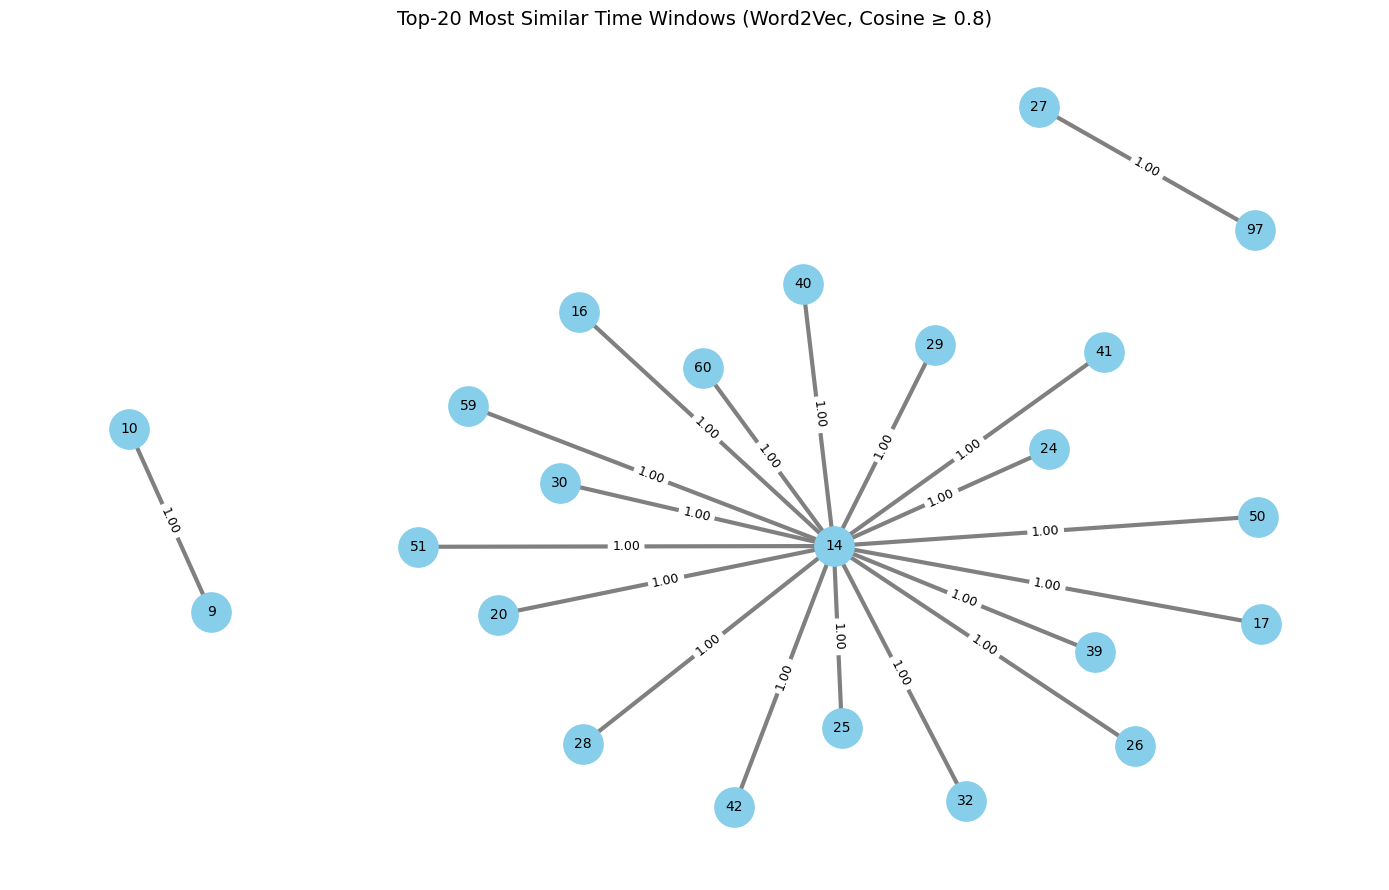

Investment Confidence Score (Last 5 windows): 85.19/100


In [17]:
print(word2v_cosine_sim.__doc__)
word2v_cosine_sim(w2v_model,documents, top_k=20, threshold=0.8)

Windows 1 & 5 → Similarity: 1.0000
Windows 1 & 12 → Similarity: 1.0000
Windows 1 & 87 → Similarity: 1.0000
Windows 5 & 12 → Similarity: 1.0000
Windows 5 & 87 → Similarity: 1.0000
Windows 6 & 49 → Similarity: 1.0000
Windows 11 & 49 → Similarity: 1.0000
Windows 33 & 49 → Similarity: 1.0000
Windows 36 & 49 → Similarity: 1.0000
Windows 38 & 49 → Similarity: 1.0000


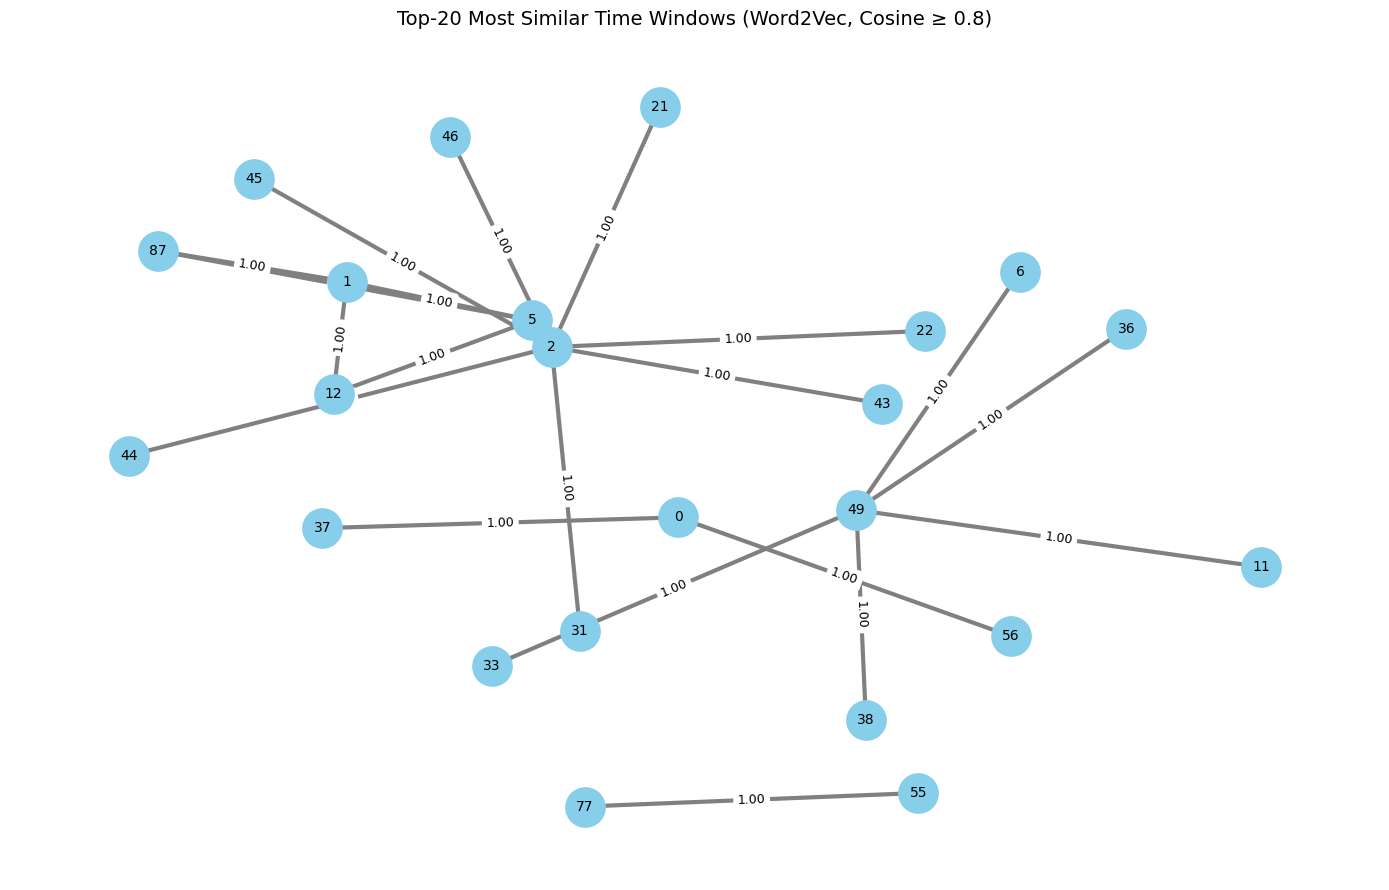

Investment Confidence Score (Last 5 windows): 87.66/100


In [18]:
word2v_cosine_sim(ft_model,documents, top_k=20, threshold=0.8)


    Visualizes top-k cosine similarity connections between time windows
    based on LSI/LDA topic vectors.
    


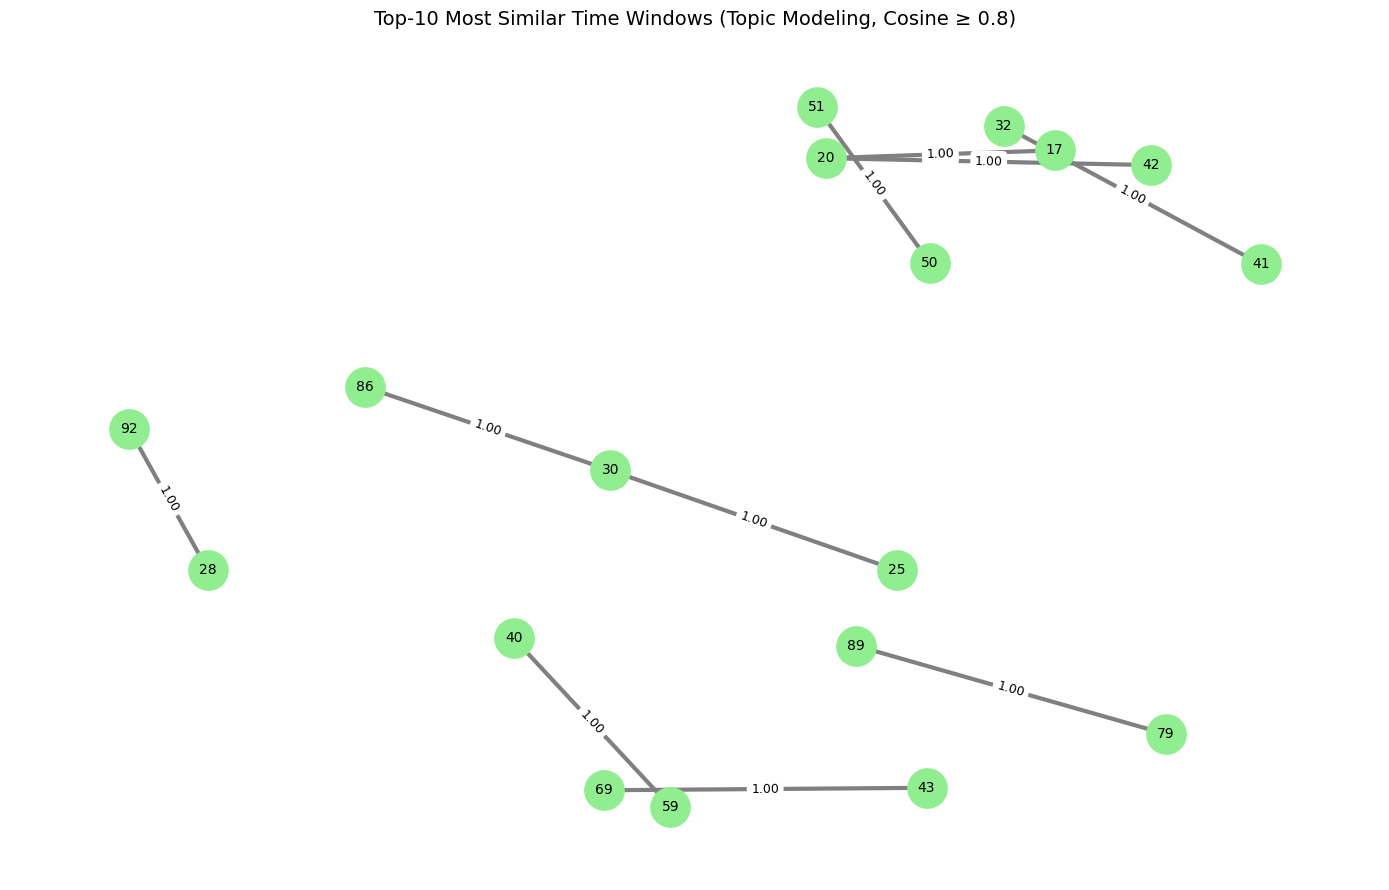

In [19]:
print(topic_model_cos_sim.__doc__)
topic_model_cos_sim(lda_model, corpus, top_k=10, threshold=0.8)

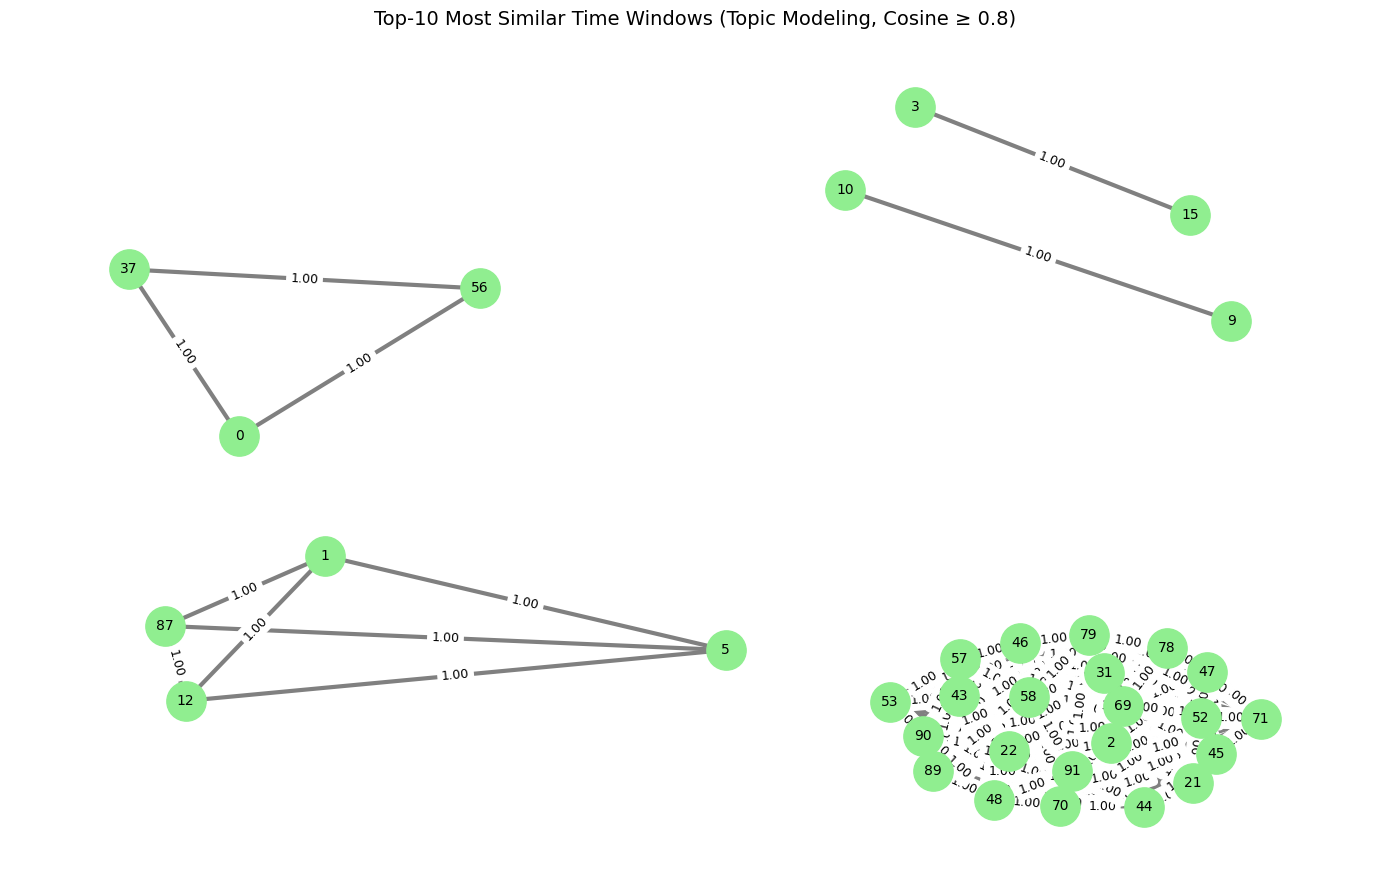

In [20]:
topic_model_cos_sim(lsi_model, corpus, top_k=10, threshold=0.8)

In [21]:
# Pull out data to check Bitcoin price
sub_dataframe(df, 0)

time           22:11:03.919435
price                    84218
date                2025-04-13
perc_change                0.0
movement                stable
window                       0
Name: 0, dtype: object